# Time domain delay scan measurement
## for cross correlation 
This script is used to do post processing on LTspice simulation results of a system with two orthogonal antennas and a varying delay between the Ey and Ex pulses. 

In [1]:
# imports 
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
from scipy import interpolate 

from scipy import optimize
import sympy 
from scipy import signal 
from scipy.signal import savgol_filter
import matplotlib.colors as mcolors
from scipy import integrate

from scipy.signal import butter, sosfiltfilt

In [2]:
# Useful constants 
consts = {
    "c": 2.99792458e8, 
    "e": 1.60217663e-19,
    "eps0": 8.854187817e-12
}

In [3]:
# useful functions 
def resample(field_arr, time_arr, fcen, df, nsample):
    """
    Resamples MEEP output to creates a uniformly spaced SI units time array and field information sampled at those times. 

    Inputs:
    field_arr: array (1-D or N-D array) of field information outputted by MEEP
    time_arr: time array (in MEEP units) representing the actual time data of MEEP simulation
    fcen: central frequency of source as defined in the settings.yaml file (MEEP units)
    df: bandwidth of source as defined in the settings.yaml file (MEEP units)
    nsample: number of time samples as defined in the settings.yaml

    Output: resampled_field and SI time array 

    FIXME: below and above intrp range gives errors 
    """
    Tucf = 1e-6/consts["c"]
    n = field_arr.shape[-1]
    if len(field_arr.shape) == 3:
        f_field = interpolate.interp1d(np.insert(time_arr, 0, 0), np.insert(field_arr,0, np.zeros_like(field_arr[:,:,0]),axis=-1), axis=-1)
    elif len(field_arr.shape) == 2:
        f_field = interpolate.interp1d(np.insert(time_arr, 0, 0), np.insert(field_arr,0, np.zeros_like(field_arr[:, 0]),axis=-1), axis=-1)
    else:
        f_field = interpolate.interp1d(np.insert(time_arr, 0, 0), np.insert(field_arr,0, 0,axis=-1), axis=-1)

    t1 = 1.0/(fcen + 0.5*df)/nsample
    newt_arr = np.arange(t1, time_arr[-1]+0.001*t1, t1)
    #if len(newt_arr ) < n:
    #    newt_arr = np.arange(t1, (n+1.1)*t1, t1)
    #elif len(newt_arr) > n:
    #    newt_arr =  np.arange(t1, (n+0.9)*t1, t1)

    # debug call 
    print(time_arr[-1])
    print(newt_arr[-1])
    resampled_field_arr = f_field(newt_arr)
    if len(field_arr.shape) == 1:
        resampled_field_arr = np.insert(resampled_field_arr, 0, 0, axis=0)
        newt_arr = np.insert(newt_arr, 0, 0, axis=0)
    return resampled_field_arr, newt_arr*Tucf

In [4]:
def hex_to_RGB(hex_str):
    """ #FFFFFF -> [255,255,255]"""
    #Pass 16 to the integer function for change of base
    return [int(hex_str[i:i+2], 16) for i in range(1,6,2)]

def get_color_gradient(c1, c2, n):
    """
    Given two hex colors, returns a color gradient
    with n colors.
    """
    assert n > 1
    c1_rgb = np.array(hex_to_RGB(c1))/255
    c2_rgb = np.array(hex_to_RGB(c2))/255
    mix_pcts = [x/(n-1) for x in range(n)]
    rgb_colors = [((1-mix)*c1_rgb + (mix*c2_rgb)) for mix in mix_pcts]
    return ["#" + "".join([format(int(round(val*255)), "02x") for val in item]) for item in rgb_colors]

Funbctions that extract information from an exported LTspice text file and get the traces ready to plot. 

In [5]:
def TD_and_freq_info_from_two_antenna_spice_sweep(path, resample_t, two_source=True):
    with open(path, 'r') as file:
        data = file.readlines()

    table = {}
    head = data[0]
    for line in data[1:]:
        if "Step Information" in line:
            print(line)
            cp = line.split("=")[1]
            if "M" in cp:
                cp = str(float(cp.split('M')[0])*1e6)
            elif 'm' in cp:
                cp = str(float(cp.split('m')[0])*0.001)
            if 'K' in cp:
                cp = str(float(cp.split('K')[0])*1e3)
            elif 'n' in cp:
                cp = str(float(cp.split('n')[0])*1e-9)
            elif 'f' in cp:
                cp = str(float(cp.split('f')[0])*1e-15)
            elif 'p' in cp:
                cp = cp.split(' ')[0]
                if 'p' in cp:
                    cp = str(float(cp.split('p')[0])*1e-12)
            table[cp] = [head.split('\n')[0].split('\t')]
        else:
            table[cp].append(line.split('\n')[0].split('\t'))

    del data

    if "V(tpEmtrY,clctrY)" in list(table.values())[0][0]:
        inpY = "V(tpEmtrY,clctrY)"
    elif "V(clctrY,tpEmtrY)" in list(table.values())[0][0]:
        inpY = "V(clctrY,tpEmtrY)"
    elif "V(tpemtry)" in list(table.values())[0][0]:
        inpY = "V(tpemtry)"
    else:
        inpY = None

    
    if "V(tpEmtrX,clctrX)" in list(table.values())[0][0]:
        inpX = "V(tpEmtrX,clctrX)"
    elif "V(clctrX,tpEmtrX)" in list(table.values())[0][0]:
        inpX = "V(clctrX,tpEmtrX)"
    elif "V(tpemtrx)" in list(table.values())[0][0]:
        inpX = "V(tpemtrx)"
    else: 
        inpX = None
        
    if "V(btmEmtrY,clctrY)" in list(table.values())[0][0]:
        outpY = "V(btmEmtrY,clctrY)" 
    elif "V(clctrY,btmEmtrY)" in list(table.values())[0][0]:
        outpY = "V(clctrY,btmEmtrY)"
    elif "V(btmemtry)" in list(table.values())[0][0]:
        outpY = "V(btmemtry)"
    else:
        outpY = "V(btmemtry)"

    if "V(btmEmtrX,clctrX)" in list(table.values())[0][0]:
        outpX = "V(btmEmtrX,clctrX)"
    elif "V(clctrX,btmEmtrX)" in list(table.values())[0][0]:
        outpX = "V(clctrX,btmEmtrX)"
    else:
        outpX = "V(btmemtrx)"

    if "I(B1)" in list(table.values())[0][0]:
        b1 = "I(B1)"
        b1_currents = []
        b1C_list = []
    elif "I(YEmissionSrc)" in list(table.values())[0][0]: 
        b1 = "I(YEmissionSrc)"
        b1_currents = []
        b1C_list = []
    else:
        b1 = None

    if "I(B2)" in list(table.values())[0][0]:
        b2 = "I(B2)"
        b2_currents = []
        b2C_list = []
    if "I(XEmissionSrc)" in list(table.values())[0][0]:
        b2 = "I(XEmissionSrc)"
        b2_currents = []
        b2C_list = []
    else: 
        b2 = None

    if "I(R5)" in list(table.values())[0][0]:
        readoutR = "I(R5)"
        readout_currents = []
        readoutC_list = []
    elif "I(readout)" in list(table.values())[0][0]:
        readoutR = "I(readout)"
        readout_currents = []
        readoutC_list = []
    else: 
        readoutR = None

    if "I(C11)" in list(table.values())[0][0]:
        end_cap = "I(C11)"
        end_capC= []
    else:
        end_cap = None

    cp_list = []
    vin_list = []
    gapY_list = []
    gapX_list = []

    if two_source:
        vinY_list = []
        vinX_list = []

    for key in table:
        ## extract the phase by stripping white space
        cp = key.split(" ")[0]
        df = pd.DataFrame(table[key][1:], columns=table[key][0])
        #print(df.columns)
        df["time"] = df["time"].astype(float)
        if inpY is not None:
            df[inpY] = df[inpY].astype(float)
        if inpX is not None:
            df[inpX] = df[inpX].astype(float)
        cp_list.append(cp)
        #print(len(df["time"].to_numpy()))
        if inpY is not None:
            finY = interpolate.interp1d(df["time"].to_numpy()*1e-15, df[inpY].to_numpy().astype(float)*1e12)
        else: 
            finY = None
        if inpX is not None:
            finX = interpolate.interp1d(df["time"].to_numpy()*1e-15, df[inpX].to_numpy().astype(float)*1e12)
        else: 
            finX = None
        
        fgapY = interpolate.interp1d(df["time"].to_numpy()*1e-15, df[outpY].to_numpy().astype(float)*1e12)
        fgapX = interpolate.interp1d(df["time"].to_numpy()*1e-15, df[outpX].to_numpy().astype(float)*1e12)
        # TODO: now we select either x or y source, but we should allow both in the future 

        if b1 is not None:
            fb1_cur = interpolate.interp1d(df["time"].to_numpy()*1e-15, df[b1].to_numpy().astype(float)*1e15)
            fb1_c = integrate.simpson(df[b1].to_numpy().astype(float)*1e15, df["time"].to_numpy()*1e-15)
            b1C_list.append(fb1_c)
            Ib1_n = fb1_cur(resample_t)
            b1_currents.append(Ib1_n)

        if b2 is not None:
            fb2_cur = interpolate.interp1d(df["time"].to_numpy()*1e-15, df[b2].to_numpy().astype(float)*1e15)
            fb2_c = integrate.simpson(df[b2].to_numpy().astype(float)*1e15, df["time"].to_numpy()*1e-15)
            b2C_list.append(fb2_c)
            Ib2_n = fb2_cur(resample_t)
            b2_currents.append(Ib2_n)

        if readoutR is not None:
            readout_cur = interpolate.interp1d(df["time"].to_numpy()*1e-15, df[readoutR].to_numpy().astype(float)*1e15)
            readout_c = integrate.simpson(df[readoutR].to_numpy().astype(float)*1e15, df["time"].to_numpy()*1e-15)
            readoutC_list.append(readout_c)
            readout_n = readout_cur(resample_t)
            readout_currents.append(readout_n)

        if end_cap is not None:
            cap_c = integrate.simpson(df[end_cap].to_numpy().astype(float)*1e15, df["time"].to_numpy()*1e-15)
            end_capC.append(cap_c)
            
        if two_source:
            if inpY is not None:
                VinY_n = finY(resample_t)
                vinY_list.append(VinY_n)
            if inpX is not None:
                VinX_n = finX(resample_t)
                vinX_list.append(VinX_n)
        else:
            if inpY is not None:
                Vin_n = finY(resample_t)
            elif inpX is not None:
                Vin_n = finX(resample_t)
            vin_list.append(Vin_n)
            
        VgapY_n= fgapY(resample_t)
        VgapX_n= fgapX(resample_t)
        gapY_list.append(VgapY_n)
        gapX_list.append(VgapX_n)

    del table
    vin_fr_list = []
    if two_source:
        vinY_fr_list = []
        vinX_fr_list = []
    vgapY_fr_list = []
    vgapX_fr_list = []
   
    for i in range(len(cp_list)):
        if two_source:
            if inpY is not None:
                vinY_fr = np.fft.fftshift(np.fft.fft(vinY_list[i], n=1*len(resample_t)))
                vinY_fr_list.append(vinY_fr)
            if inpX is not None:
                vinX_fr = np.fft.fftshift(np.fft.fft(vinX_list[i], n=1*len(resample_t)))
                vinX_fr_list.append(vinX_fr)
        else:
            vin_fr = np.fft.fftshift(np.fft.fft(vin_list[i], n=1*len(resample_t)))
            vin_fr_list.append(vin_fr)
        vgapY_fr = np.fft.fftshift(np.fft.fft(gapY_list[i], n=1*len(resample_t)))
        vgapY_fr_list.append(vgapY_fr)
        vgapX_fr = np.fft.fftshift(np.fft.fft(gapX_list[i], n=1*len(resample_t)))
        vgapX_fr_list.append(vgapX_fr)
    freq = np.fft.fftshift(np.fft.fftfreq(4*len(resample_t), d=resample_t[1]-resample_t[0]))
    del df

    if two_source:
        if  b1 is not None and  b2 is not None:
            if readoutR is not None:
                if end_cap is not None:
                     return cp_list, vinY_list, vinX_list, gapY_list, gapX_list, vinY_fr_list, vinX_fr_list, vgapY_fr_list, vgapX_fr_list, freq, b1_currents, b1C_list, b2_currents, b2C_list, readout_currents, readoutC_list, end_capC
                return cp_list, vinY_list, vinX_list, gapY_list, gapX_list, vinY_fr_list, vinX_fr_list, vgapY_fr_list, vgapX_fr_list, freq, b1_currents, b1C_list, b2_currents, b2C_list, readout_currents, readoutC_list
            return cp_list, vinY_list, vinX_list, gapY_list, gapX_list, vinY_fr_list, vinX_fr_list, vgapY_fr_list, vgapX_fr_list, freq, b1_currents, b1C_list, b2_currents, b2C_list
        elif b1 is not None:
            return cp_list, vinY_list, vinX_list, gapY_list, gapX_list, vinY_fr_list, vinX_fr_list, vgapY_fr_list, vgapX_fr_list, freq, b1_currents, b1C_list
        elif b2 is not None:
            return cp_list, vinY_list, vinX_list, gapY_list, gapX_list, vinY_fr_list, vinX_fr_list, vgapY_fr_list, vgapX_fr_list, freq, b2_currents, b2C_list
        return cp_list, vinY_list, vinX_list, gapY_list, gapX_list, vinY_fr_list, vinX_fr_list, vgapY_fr_list, vgapX_fr_list, freq
    else:
        return cp_list, vin_list, gapY_list, gapX_list, vin_fr_list, vgapY_fr_list, vgapX_fr_list, freq

        

In [6]:
def TD_and_freq_info_from_two_antenna_spice_sweep_cumltv_chrg(path, resample_t, two_source=True):
    """Takes the path specifications for a txt file export of an LTspice simulation sweeping over a parameter
    The function extracts the time domain and freqency information from the file and retunrns it in lists """

    with open(path, 'r') as file:
        data = file.readlines()

    table = {}
    head = data[0]
    for line in data[1:]:
        if "Step Information" in line:
            print(line)
            cp = line.split("=")[1]
            if 'm' in cp:
                cp = str(float(cp.split('m')[0])*0.001)
            elif 'n' in cp:
                cp = str(float(cp.split('n')[0])*1e-9)
            elif 'f' in cp:
                cp = str(float(cp.split('f')[0])*1e-15)
            elif 'K' in cp:
                cp = str(float(cp.split('K')[0])*1e3)
            elif 'p' in cp:
                cp = cp.split(' ')[0]
                if 'p' in cp:
                    cp = str(float(cp.split('p')[0])*1e-12)
            table[cp] = [head.split('\n')[0].split('\t')]
        else:
            table[cp].append(line.split('\n')[0].split('\t'))

    if "V(tpEmtrY,clctrY)" in list(table.values())[0][0]:
        inpY = "V(tpEmtrY,clctrY)"
    elif "V(clctrY,tpEmtrY)" in list(table.values())[0][0]:
        inpY = "V(clctrY,tpEmtrY)"
    elif "V(tpemtry)" in list(table.values())[0][0]:
        inpY = "V(tpemtry)"
    else:
        inpY = None

    
    if "V(tpEmtrX,clctrX)" in list(table.values())[0][0]:
        inpX = "V(tpEmtrX,clctrX)"
    elif "V(clctrX,tpEmtrX)" in list(table.values())[0][0]:
        inpX = "V(clctrX,tpEmtrX)"
    elif "V(tpemtrx)" in list(table.values())[0][0]:
        inpX = "V(tpemtrx)"
    else: 
        inpX = None
        
    if "V(btmEmtrY,clctrY)" in list(table.values())[0][0]:
        outpY = "V(btmEmtrY,clctrY)" 
    elif "V(clctrY, btmEmtrY)" in list(table.values())[0][0]:
        outpY = "V(clctrY,btmEmtrY)"
    elif "V(btmemtry)" in list(table.values())[0][0]:
        outpY = "V(btmemtry)"
    else:
        outpY = "V(btmemtry)"

    if "V(btmEmtrX,clctrX)" in list(table.values())[0][0]:
        outpX = "V(btmEmtrX,clctrX)"
    elif "V(clctrX,btmEmtrX)" in list(table.values())[0][0]:
        outpX = "V(clctrX,btmEmtrX)"
    else:
        outpX = "V(btmemtrx)"

    if "I(B1)" in list(table.values())[0][0]:
        b1 = "I(B1)"
        b1_currents = []
        b1C_list = []
    elif "I(YEmissionSrc)" in list(table.values())[0][0]: 
        b1 = "I(YEmissionSrc)"
        b1_currents = []
        b1C_list = []
    else:
        b1 = None

    if "I(B2)" in list(table.values())[0][0]:
        b2 = "I(B2)"
        b2_currents = []
        b2C_list = []
    if "I(XEmissionSrc)" in list(table.values())[0][0]:
        b2 = "I(XEmissionSrc)"
        b2_currents = []
        b2C_list = []
    else: 
        b2 = None

    if "I(R5)" in list(table.values())[0][0]:
        readoutR = "I(R5)"
        readout_currents = []
        readoutC_list = []
        readout_cumilitive_charge = []
    elif "I(readout)" in list(table.values())[0][0]:
        readoutR = "I(readout)"
        readout_currents = []
        readoutC_list = []
        readout_cumilitive_charge = []
    else: 
        readoutR = None

    if "I(C11)" in list(table.values())[0][0]:
        end_cap = "I(C11)"
        end_capC= []
    else:
        end_cap = None

    cp_list = []
    vin_list = []
    gapY_list = []
    gapX_list = []

    if two_source:
        vinY_list = []
        vinX_list = []

    for key in table:
        ## extract the phase by stripping white space
        cp = key.split(" ")[0]
        df = pd.DataFrame(table[key][1:], columns=table[key][0])
        #print(df.columns)
        df["time"] = df["time"].astype(float)
        if inpY is not None:
            df[inpY] = df[inpY].astype(float)
        if inpX is not None:
            df[inpX] = df[inpX].astype(float)
        cp_list.append(cp)
        #print(len(df["time"].to_numpy()))
        if inpY is not None:
            finY = interpolate.interp1d(df["time"].to_numpy()*1e-15, df[inpY].to_numpy().astype(float)*1e12)
        else: 
            finY = None
        if inpX is not None:
            finX = interpolate.interp1d(df["time"].to_numpy()*1e-15, df[inpX].to_numpy().astype(float)*1e12)
        else: 
            finX = None
        
        fgapY = interpolate.interp1d(df["time"].to_numpy()*1e-15, df[outpY].to_numpy().astype(float)*1e12)
        fgapX = interpolate.interp1d(df["time"].to_numpy()*1e-15, df[outpX].to_numpy().astype(float)*1e12)
        # TODO: now we select either x or y source, but we should allow both in the future 

        if b1 is not None:
            fb1_cur = interpolate.interp1d(df["time"].to_numpy()*1e-15, df[b1].to_numpy().astype(float)*1e15)
            fb1_c = integrate.simpson(df[b1].to_numpy().astype(float)*1e15, df["time"].to_numpy()*1e-15)
            b1C_list.append(fb1_c)
            Ib1_n = fb1_cur(resample_t)
            b1_currents.append(Ib1_n)

        if b2 is not None:
            fb2_cur = interpolate.interp1d(df["time"].to_numpy()*1e-15, df[b2].to_numpy().astype(float)*1e15)
            fb2_c = integrate.simpson(df[b2].to_numpy().astype(float)*1e15, df["time"].to_numpy()*1e-15)
            b2C_list.append(fb2_c)
            Ib2_n = fb2_cur(resample_t)
            b2_currents.append(Ib2_n)

        if readoutR is not None:
            readout_cur = interpolate.interp1d(df["time"].to_numpy()*1e-15, df[readoutR].to_numpy().astype(float)*1e15)
            readout_c = integrate.simpson(df[readoutR].to_numpy().astype(float)*1e15, df["time"].to_numpy()*1e-15)
            readoutC_list.append(readout_c)
            readout_n = readout_cur(resample_t)
            readout_currents.append(readout_n)
            readout_cum_c = integrate.cumulative_simpson(readout_n, x=resample_t)
            readout_cumilitive_charge.append(readout_cum_c)

        if end_cap is not None:
            cap_c = integrate.simps(df[end_cap].to_numpy().astype(float)*1e15, df["time"].to_numpy()*1e-15)
            end_capC.append(cap_c)
            
        if two_source:
            if inpY is not None:
                VinY_n = finY(resample_t)
                vinY_list.append(VinY_n)
            if inpX is not None:
                VinX_n = finX(resample_t)
                vinX_list.append(VinX_n)
        else:
            if inpY is not None:
                Vin_n = finY(resample_t)
            elif inpX is not None:
                Vin_n = finX(resample_t)
            vin_list.append(Vin_n)
            
        VgapY_n= fgapY(resample_t)
        VgapX_n= fgapX(resample_t)
        gapY_list.append(VgapY_n)
        gapX_list.append(VgapX_n)

    vin_fr_list = []
    if two_source:
        vinY_fr_list = []
        vinX_fr_list = []
    vgapY_fr_list = []
    vgapX_fr_list = []
   
    for i in range(len(cp_list)):
        if two_source:
            if inpY is not None:
                vinY_fr = np.fft.fftshift(np.fft.fft(vinY_list[i], n=4*len(resample_t)))
                vinY_fr_list.append(vinY_fr)
            if inpX is not None:
                vinX_fr = np.fft.fftshift(np.fft.fft(vinX_list[i], n=4*len(resample_t)))
                vinX_fr_list.append(vinX_fr)
        else:
            vin_fr = np.fft.fftshift(np.fft.fft(vin_list[i], n=4*len(resample_t)))
            vin_fr_list.append(vin_fr)
        vgapY_fr = np.fft.fftshift(np.fft.fft(gapY_list[i], n=4*len(resample_t)))
        vgapY_fr_list.append(vgapY_fr)
        vgapX_fr = np.fft.fftshift(np.fft.fft(gapX_list[i], n=4*len(resample_t)))
        vgapX_fr_list.append(vgapX_fr)
    freq = np.fft.fftshift(np.fft.fftfreq(4*len(resample_t), d=resample_t[1]-resample_t[0]))

    if two_source:
        if  b1 is not None and  b2 is not None:
            if readoutR is not None:
                if end_cap is not None:
                     return cp_list, vinY_list, vinX_list, gapY_list, gapX_list, vinY_fr_list, vinX_fr_list, vgapY_fr_list, vgapX_fr_list, freq, b1_currents, b1C_list, b2_currents, b2C_list, readout_currents, readoutC_list, end_capC
                return cp_list, vinY_list, vinX_list, gapY_list, gapX_list, vinY_fr_list, vinX_fr_list, vgapY_fr_list, vgapX_fr_list, freq, b1_currents, b1C_list, b2_currents, b2C_list, readout_currents, readoutC_list, readout_cumilitive_charge
            return cp_list, vinY_list, vinX_list, gapY_list, gapX_list, vinY_fr_list, vinX_fr_list, vgapY_fr_list, vgapX_fr_list, freq, b1_currents, b1C_list, b2_currents, b2C_list
        return cp_list, vinY_list, vinX_list, gapY_list, gapX_list, vinY_fr_list, vinX_fr_list, vgapY_fr_list, vgapX_fr_list, freq
    else:
        return cp_list, vin_list, gapY_list, gapX_list, vin_fr_list, vgapY_fr_list, vgapX_fr_list, freq


### Read imported SPICE text files, iterate over the data tables from different sweep values, resample time domain data, calculate integrals and Fourier transforms

Step Information: Delt=-75  (Step: 1/7)

Step Information: Delt=-74.25  (Step: 2/7)

Step Information: Delt=-73.5  (Step: 3/7)

Step Information: Delt=-72.75  (Step: 4/7)

Step Information: Delt=-72  (Step: 5/7)

Step Information: Delt=-71.25  (Step: 6/7)

Step Information: Delt=-70.5  (Step: 7/7)

Amplitude: -75.0
Ey emission: -7.836110714931004e-17 C
Ex emission: -1.5942357876875982e-19 C
Readout charge: -7.795174399209443e-17 C
Missing electrons: -2
Amplitude: -74.25
Ey emission: -7.677785611942139e-17 C
Ex emission: -1.5942026287762735e-19 C
Readout charge: -7.639440680797256e-17 C
Missing electrons: -1
Amplitude: -73.5
Ey emission: -7.604728727446271e-17 C
Ex emission: -1.5941381883886503e-19 C
Readout charge: -7.571799689828438e-17 C
Missing electrons: -1
Amplitude: -72.75
Ey emission: -7.706314999471627e-17 C
Ex emission: -1.5941468586806418e-19 C
Readout charge: -7.677717593896646e-17 C
Missing electrons: -1
Amplitude: -72.0
Ey emission: -7.862524823722181e-17 C
Ex emission: -1

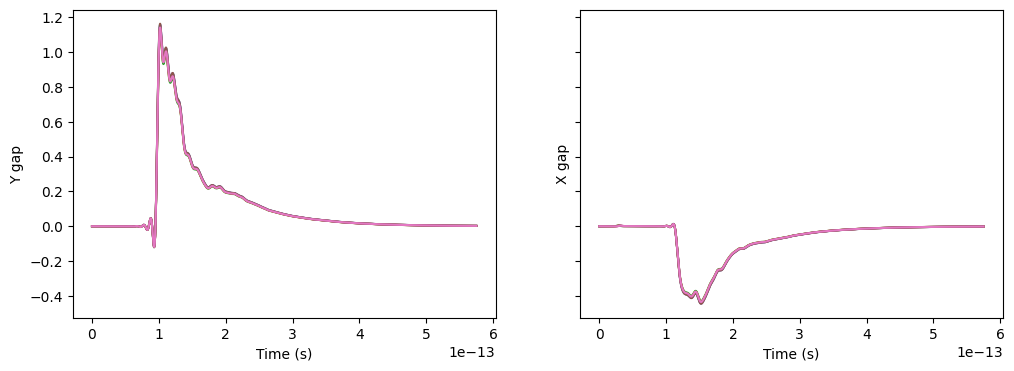

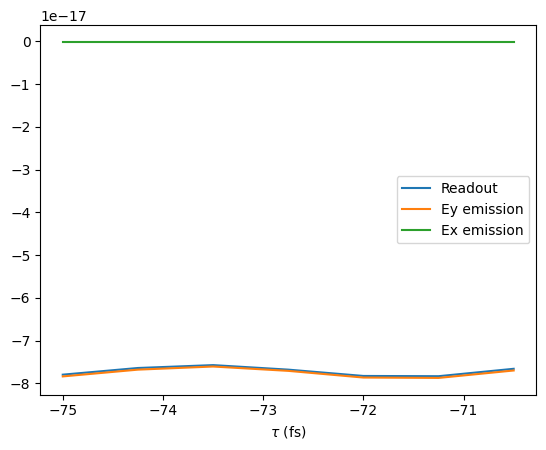

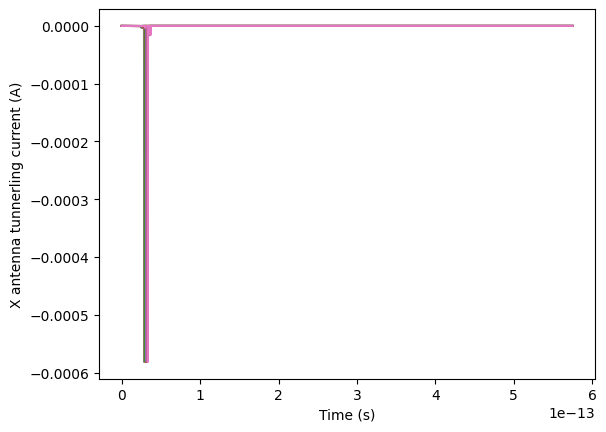

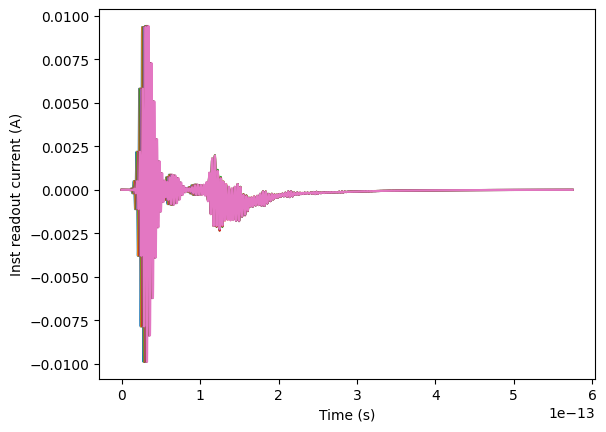

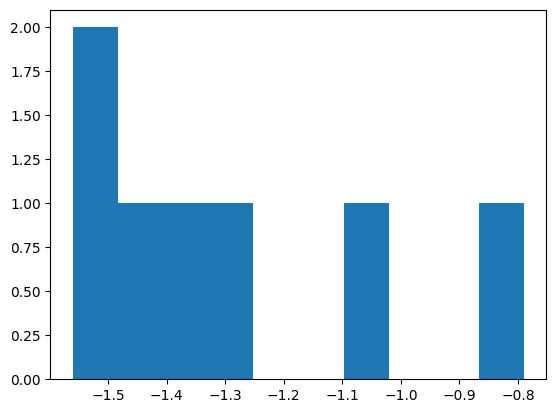

In [ ]:
path_d1 = "coupled_antennas_with_current_td1.txt"
t_samp_d1 = np.arange(0, 574.99e-15, 0.01e-15)
delay_list_d1, vinY_list_d1, vinX_list_d1, gapY_list_d1, gapX_list_d1, vinY_fr_list_d1, vinX_fr_list_d1, vgapY_fr_list_d1, vgapX_fr_list_d1, freq_d1, b1_currents_d1, b1C_list_d1, b2_currents_d1, b2C_list_d1, read_currents_d1, readC_list_d1 = TD_and_freq_info_from_two_antenna_spice_sweep(path_d1, t_samp_d1, two_source=True)
delay_list_d1 = np.array(delay_list_d1, dtype=float)
np.savetxt("extracted_charge_del1.txt", [delay_list_d1, readC_list_d1, b1C_list_d1, b2C_list_d1], fmt='%.18e')

missing_electrons_d1 = []
for i in range(len(delay_list_d1)):
    print("Amplitude:", delay_list_d1[i])
    print("Ey emission:",  b1C_list_d1[i], "C")
    print("Ex emission:",  b2C_list_d1[i], "C")
    print("Readout charge:",  readC_list_d1[i], "C")
    print("Missing electrons:",  round((b1C_list_d1[i] - b2C_list_d1[i] - readC_list_d1[i])/consts["e"]))
    missing_electrons_d1.append((b1C_list_d1[i] - b2C_list_d1[i] - readC_list_d1[i])/consts["e"])
    

dt = t_samp_d1[1] - t_samp_d1[0]    # 0.01 fs
fs = 1.0 / dt                         # ~100 PHz
fc = 100e12   # [Hz] – adjust between 30–80 THz if needed
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
#plt.plot(amp_list_d10, b1C_lis__d1, label="Y emission")
for i in range(len(delay_list_d1)):
    order = 6
    sos = butter(order, fc, btype='low', fs=fs, output='sos')
    gapX_butter = sosfiltfilt(sos, gapX_list_d1[i]) 
    gapY_butter = sosfiltfilt(sos, gapY_list_d1[i]) 
    # ind = np.argmax(t_samp_v1 >1.50e-13)
    # avg_gapX_voltage = np.mean(gapX_list_d10[i][ind:])
    axs[1].plot(t_samp_d1, gapX_butter, label="Ex {} V".format(1e12*delay_list_d1[i]))
    axs[0].plot(t_samp_d1, gapY_butter, label="Ex {} V".format(1e12*delay_list_d1[i]))
    #plt.plot(t_samp_d10, gapX_lis__d1[i], '--', alpha=0.5)
#plt.xlim([0.34e-13, 0.48e-13])
#axs[0].legend(loc=3)
#axs[1].legend(loc=2)
axs[0].set_xlabel("Time (s)")
axs[1].set_xlabel("Time (s)")
axs[0].set_ylabel("Y gap")
axs[1].set_ylabel("X gap")
plt.show()

plt.plot(delay_list_d1, readC_list_d1, label="Readout")
plt.plot(delay_list_d1, b1C_list_d1, label="Ey emission")
plt.plot(delay_list_d1, b2C_list_d1, label="Ex emission")
plt.legend()
plt.xlabel(r"$\tau$ (fs)")
plt.show()

for i in range(len(delay_list_d1)):
    plt.plot(t_samp_d1, b2_currents_d1[i], label="Ex : {} V".format(round(delay_list_d1[i], 3)))
#plt.xlim([1.8e-13, 2e-13])
#plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("X antenna tunnerling current (A)")
plt.show()


for i in range(len(delay_list_d1)):
    plt.plot(t_samp_d1, read_currents_d1[i], label="Ex amp {} V".format(round(delay_list_d1[i]*1e12, 3)))
plt.xlabel("Time (s)")
plt.ylabel("Inst readout current (A)")
#plt.legend()
plt.show()

plt.hist(missing_electrons_d1)
plt.show()

In [ ]:
data_d1 = np.loadtxt("extracted_charge_del1.txt")
delay_list_d1 = data_d1[0, :]
readC_list_d1 = data_d1[1, :]
b1C_list_d1 = data_d1[2, :]
b2C_list_d1 = data_d1[3, :]

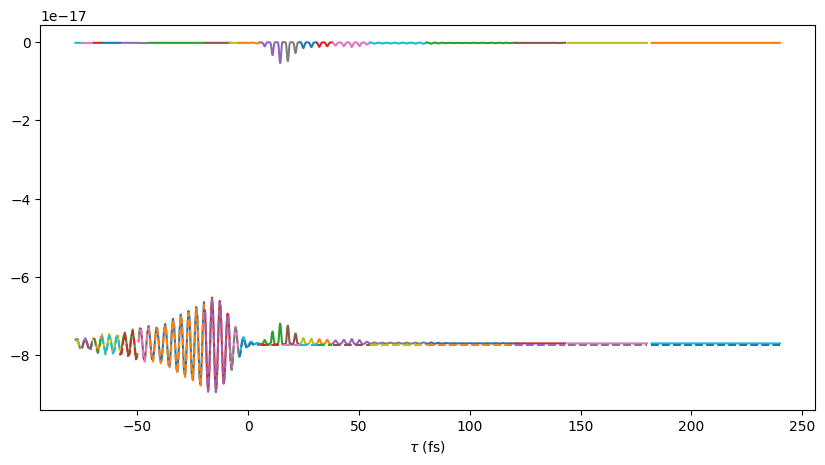

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(delay_list_d1, readC_list_d1, label="Readout")
plt.plot(delay_list_d1, b1C_list_d1, '--', label="Ey emission")
plt.plot(delay_list_d1, b2C_list_d1, label="Ex emission")

plt.plot(delay_list_d2, readC_list_d2, label="Readout")
plt.plot(delay_list_d2, b1C_list_d2, '--', label="Ey emission")
plt.plot(delay_list_d2, b2C_list_d2, label="Ex emission")

#plt.legend()
plt.xlabel(r"$\tau$ (fs)")
plt.show()

In [ ]:
readout_all = np.concatenate((readC_list_d1, readC_list_d2, readC_list_d3, readC_list_d4, readC_list_d5))

emission_y_all = np.concatenate((b1C_list_d1, b1C_list_d2, b1C_list_d3, b1C_list_d4, b1C_list_d5))

emission_x_all = np.concatenate((b2C_list_d1, b2C_list_d2, b2C_list_d3, b2C_list_d4, b2C_list_d5))

delays_all = np.concatenate((delay_list_d1, delay_list_d2, delay_list_d3, delay_list_d4, delay_list_d5))

sort_ind = np.argsort(delays_all)

delays_all = delays_all[sort_ind]
readout_all = readout_all[sort_ind]
emission_y_all = emission_y_all[sort_ind]
emission_x_all = emission_x_all[sort_ind]

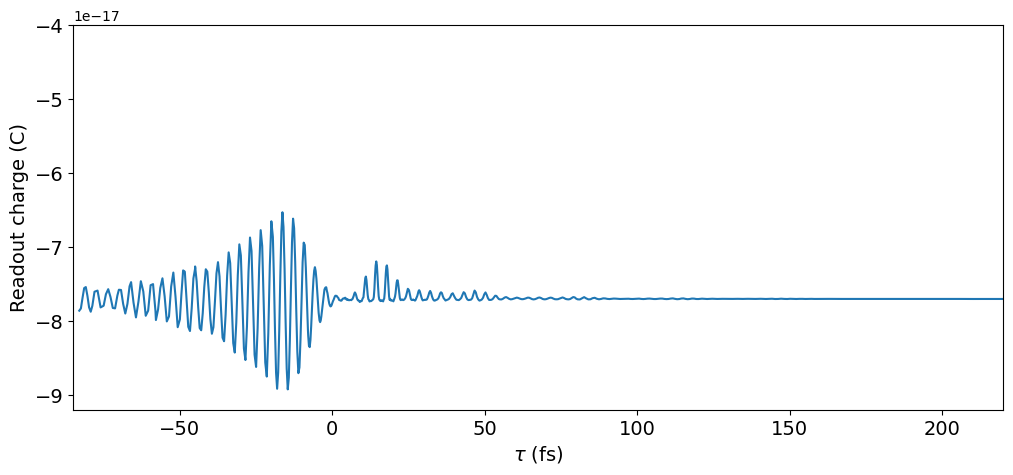

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.plot(delays_all, readout_all, label="Readout")
ax.set_xlim([0, 220])
ax.set_ylim([-9.2e-17, -4e-17])
ax.set_xlabel(r"$\tau$ (fs)", fontsize=14)
ax.set_ylabel("Readout charge (C)", fontsize=14)
ax.tick_params(axis='both', labelsize=14)
plt.savefig("last_fig_cross_correlation_4.svg", format="SVG")
plt.show()
#plt.legend()
